In [1]:
import polars as pl
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, SplineTransformer
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline, make_pipeline


# Lecture 2.7 - Examples of proper model comparison via cross-validation and grid search

**Objective.** In this lecture, we will see how to properly compare the implementation of two different approaches using cross-validation and grid search.

**Aligator Example.** 

1. Use polynomials and splines to model the relationship between the features and the target variable, 
2. Compare OLS and kNN regressors,  and 
3. Use a `GridSearchCV` to find the best hyperparameters for each model.


**Grid Search Approaches.**

1. **Easy but combersome.** Use a `KFold` cross-validation to compare the performance of a `LogisticRegression` and a `RandomForestClassifier` on the `aligator` dataset. 
2. **Better but more complex.** Use a `GridSearchCV` to find the best hyperparameters for both models, including the non-linear transformations and regressor.


#### Load the data

In [4]:
(aligator :=
 pl.read_csv('data/alligator_length_weight.csv')
)

Length (in),Weight (lb)
i64,i64
58,28
61,44
63,33
68,39
69,36
…,…
94,110
94,130
114,197


In [5]:
(X_gator :=
 aligator
 .drop('Weight (lb)')
 .to_pandas()
)

,Length (in)
0,58
1,61
2,63
3,68
4,69
5,72
6,72
7,74
8,74
9,76


In [6]:
(y_gator :=
 aligator
 .get_column('Weight (lb)'))

Weight (lb)
i64
28
44
33
39
36
…
110
130
197


#### Visualize the relationship between the features and the target variable

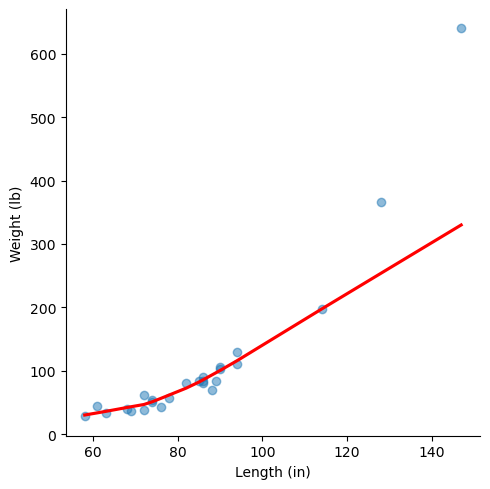

In [38]:
sns.lmplot(aligator,
           x = 'Length (in)',
           y = 'Weight (lb)',
           lowess=True,
           scatter_kws={'alpha': 0.5},
           line_kws={'color':'red'}
           )

## Approch 1: Easy but combersome

**Goal.** Use a `KFold` cross-validation to implement a separate grid search for the combinations of non-linear transformations and regressors.
* **Transforms.** `PolynomialFeatures` with degrees 1, 2, and 3, and `SplineTransformer` with various number of knots.
* **Regressors.** `LinearRegression` and `KNeighborsRegressor`.

#### Define the cross-validation strategy

In [8]:
(folds := KFold(n_splits=3, shuffle=True, random_state=1490)
)

KFold(n_splits=3, random_state=1490, shuffle=True)

#### Combination 1: `PolynomialFeatures` and `LinearRegression`

In [9]:
(model_LR_poly :=
 make_pipeline(StandardScaler(),
               PolynomialFeatures(),
               LinearRegression())
)


,steps,"[('standardscaler', ...), ('polynomialfeatures', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,degree,2
,interaction_only,False
,include_bias,True
,order,'C'


In [10]:
model_LR_poly.get_params()

{'memory': None,
 'steps': [('standardscaler', StandardScaler()),
  ('polynomialfeatures', PolynomialFeatures()),
  ('linearregression', LinearRegression())],
 'transform_input': None,
 'verbose': False,
 'standardscaler': StandardScaler(),
 'polynomialfeatures': PolynomialFeatures(),
 'linearregression': LinearRegression(),
 'standardscaler__copy': True,
 'standardscaler__with_mean': True,
 'standardscaler__with_std': True,
 'polynomialfeatures__degree': 2,
 'polynomialfeatures__include_bias': True,
 'polynomialfeatures__interaction_only': False,
 'polynomialfeatures__order': 'C',
 'linearregression__copy_X': True,
 'linearregression__fit_intercept': True,
 'linearregression__n_jobs': None,
 'linearregression__positive': False,
 'linearregression__tol': 1e-06}

In [11]:
(grid_LR_poly :=
 {'polynomialfeatures__degree':[1,2,3],
  'polynomialfeatures__include_bias':[True, False],
  'linearregression__fit_intercept':[True, False]
  }
 )

{'polynomialfeatures__degree': [1, 2, 3],
 'polynomialfeatures__include_bias': [True, False],
 'linearregression__fit_intercept': [True, False]}

In [12]:
(grid_search_LR_poly :=
 GridSearchCV(model_LR_poly, grid_LR_poly, cv=folds, n_jobs=-1, verbose=3, scoring='neg_mean_squared_error')
 )

,estimator,Pipeline(step...egression())])
,param_grid,"{'linearregression__fit_intercept': [True, False], 'polynomialfeatures__degree': [1, 2, ...], 'polynomialfeatures__include_bias': [True, False]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [13]:
grid_search_LR_poly.fit(X_gator, y_gator)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,estimator,Pipeline(step...egression())])
,param_grid,"{'linearregression__fit_intercept': [True, False], 'polynomialfeatures__degree': [1, 2, ...], 'polynomialfeatures__include_bias': [True, False]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [14]:
grid_search_LR_poly.best_params_, grid_search_LR_poly.best_score_

({'linearregression__fit_intercept': False,
  'polynomialfeatures__degree': 2,
  'polynomialfeatures__include_bias': True},
 np.float64(-700.9450066331519))

#### Combination 2: `SplineTransformer` and `LinearRegression`

In [15]:
(model_LR_spline :=
 make_pipeline(StandardScaler(),
               SplineTransformer(),
               LinearRegression(),
              )
)

,steps,"[('standardscaler', ...), ('splinetransformer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_knots,5
,degree,3
,knots,'uniform'
,extrapolation,'constant'


In [16]:
model_LR_spline.get_params()

{'memory': None,
 'steps': [('standardscaler', StandardScaler()),
  ('splinetransformer', SplineTransformer()),
  ('linearregression', LinearRegression())],
 'transform_input': None,
 'verbose': False,
 'standardscaler': StandardScaler(),
 'splinetransformer': SplineTransformer(),
 'linearregression': LinearRegression(),
 'standardscaler__copy': True,
 'standardscaler__with_mean': True,
 'standardscaler__with_std': True,
 'splinetransformer__degree': 3,
 'splinetransformer__extrapolation': 'constant',
 'splinetransformer__include_bias': True,
 'splinetransformer__knots': 'uniform',
 'splinetransformer__n_knots': 5,
 'splinetransformer__order': 'C',
 'splinetransformer__sparse_output': False,
 'linearregression__copy_X': True,
 'linearregression__fit_intercept': True,
 'linearregression__n_jobs': None,
 'linearregression__positive': False,
 'linearregression__tol': 1e-06}

In [17]:
(grid_LR_spline :=
 {'splinetransformer__n_knots':[3,4,5,6,7,8],
  'linearregression__fit_intercept':[True, False]
  }
 )


{'splinetransformer__n_knots': [3, 4, 5, 6, 7, 8],
 'linearregression__fit_intercept': [True, False]}

In [18]:
(grid_search_LR_spline :=
 GridSearchCV(model_LR_spline, grid_LR_spline, cv=folds, n_jobs=-1, verbose=3, scoring='neg_mean_squared_error')
 )


,estimator,Pipeline(step...egression())])
,param_grid,"{'linearregression__fit_intercept': [True, False], 'splinetransformer__n_knots': [3, 4, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [19]:
grid_search_LR_spline.fit(X_gator, y_gator)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,estimator,Pipeline(step...egression())])
,param_grid,"{'linearregression__fit_intercept': [True, False], 'splinetransformer__n_knots': [3, 4, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [20]:
grid_search_LR_spline.best_params_, grid_search_LR_spline.best_score_


({'linearregression__fit_intercept': False, 'splinetransformer__n_knots': 4},
 np.float64(-14127.291524642815))

## <font color="red">Exercise 2.7.1</font>

**Tasks.**
1.  Implement the same approaches (poly & spline) for the `KNeighborsRegressor`,
2.  Compare the results with the `LinearRegression`, and
3.  Answer the questions: 
    - which approach is better for this dataset?
    - What would happen if we wanted to compare dozens of different models and transformations?

In [21]:
# Your code here (add cells as needed)

<font color="orange">
Your answers here.
</font>

## Approach 2: Better but more complex

Now we will implement all four combinations of non-linear transformations and regressors in a single `GridSearchCV` and compare the results.

#### Generic model pipeline with "holes" for the non-linear transformation and the regressor

In [22]:
(model_all :=
 Pipeline(
     steps= [ ('scale',StandardScaler()),
              ('transform', None),
              ('model',  TransformedTargetRegressor())
            ]
         )
)

,steps,"[('scale', ...), ('transform', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,regressor,None
,transformer,None
,func,None
,inverse_func,None


#### Understanding the base names

In [23]:
model_all.get_params()

{'memory': None,
 'steps': [('scale', StandardScaler()),
  ('transform', None),
  ('model', TransformedTargetRegressor())],
 'transform_input': None,
 'verbose': False,
 'scale': StandardScaler(),
 'transform': None,
 'model': TransformedTargetRegressor(),
 'scale__copy': True,
 'scale__with_mean': True,
 'scale__with_std': True,
 'model__check_inverse': True,
 'model__func': None,
 'model__inverse_func': None,
 'model__regressor': None,
 'model__transformer': None}

#### Building the grid components

In [24]:

PolynomialFeatures().get_params()

{'degree': 2, 'include_bias': True, 'interaction_only': False, 'order': 'C'}

In [25]:
(poly_params :=
 {
     'transform':[PolynomialFeatures()],  # Needs to be in a list/tuple!
     'transform__degree':[1,2,3],
     'transform__include_bias':[True, False],
 }
)

{'transform': [PolynomialFeatures()],
 'transform__degree': [1, 2, 3],
 'transform__include_bias': [True, False]}

In [26]:
SplineTransformer().get_params()

{'degree': 3,
 'extrapolation': 'constant',
 'include_bias': True,
 'knots': 'uniform',
 'n_knots': 5,
 'order': 'C',
 'sparse_output': False}

In [27]:
(spline_params :=
 {
     'transform':[SplineTransformer()],
     'transform__n_knots':[3, 4, 5, 6, 7, 8],
 }
)

{'transform': [SplineTransformer()], 'transform__n_knots': [3, 4, 5, 6, 7, 8]}

In [28]:
model_all.get_params()

{'memory': None,
 'steps': [('scale', StandardScaler()),
  ('transform', None),
  ('model', TransformedTargetRegressor())],
 'transform_input': None,
 'verbose': False,
 'scale': StandardScaler(),
 'transform': None,
 'model': TransformedTargetRegressor(),
 'scale__copy': True,
 'scale__with_mean': True,
 'scale__with_std': True,
 'model__check_inverse': True,
 'model__func': None,
 'model__inverse_func': None,
 'model__regressor': None,
 'model__transformer': None}

In [29]:
LinearRegression().get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

In [30]:
(LR_params :=
 {
     'model__regressor':[LinearRegression()],
     'model__regressor__fit_intercept':[True, False],
 }
)


{'model__regressor': [LinearRegression()],
 'model__regressor__fit_intercept': [True, False]}

In [31]:
KNeighborsRegressor().get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

In [32]:
(kNN_params :=
 {
     'model__regressor':[KNeighborsRegressor()],
     'model__regressor__n_neighbors':[2,3,4,5],
 }
)

{'model__regressor': [KNeighborsRegressor()],
 'model__regressor__n_neighbors': [2, 3, 4, 5]}

#### Make a grid of all possible combinations of the non-linear transformations and regressors

In [33]:
(grid_all :=
 [ poly_params | LR_params,
   poly_params | kNN_params,
   spline_params | LR_params,
   spline_params | kNN_params,
 ]

)

[{'transform': [PolynomialFeatures()],
  'transform__degree': [1, 2, 3],
  'transform__include_bias': [True, False],
  'model__regressor': [LinearRegression()],
  'model__regressor__fit_intercept': [True, False]},
 {'transform': [PolynomialFeatures()],
  'transform__degree': [1, 2, 3],
  'transform__include_bias': [True, False],
  'model__regressor': [KNeighborsRegressor()],
  'model__regressor__n_neighbors': [2, 3, 4, 5]},
 {'transform': [SplineTransformer()],
  'transform__n_knots': [3, 4, 5, 6, 7, 8],
  'model__regressor': [LinearRegression()],
  'model__regressor__fit_intercept': [True, False]},
 {'transform': [SplineTransformer()],
  'transform__n_knots': [3, 4, 5, 6, 7, 8],
  'model__regressor': [KNeighborsRegressor()],
  'model__regressor__n_neighbors': [2, 3, 4, 5]}]

#### Create the `GridSearchCV` object and fit it to the data

In [34]:
(grid_search_all :=
 GridSearchCV(model_all, grid_all, cv = 3, n_jobs=-1, verbose=3, scoring='neg_mean_squared_error')
)

,estimator,Pipeline(step...Regressor())])
,param_grid,"[{'model__regressor': [LinearRegression()], 'model__regressor__fit_intercept': [True, False], 'transform': [PolynomialFeatures()], 'transform__degree': [1, 2, ...], ...}, {'model__regressor': [KNeighborsRegressor()], 'model__regressor__n_neighbors': [2, 3, ...], 'transform': [PolynomialFeatures()], 'transform__degree': [1, 2, ...], ...}, ...]"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [35]:
grid_search_all.fit(X_gator, y_gator)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


,estimator,Pipeline(step...Regressor())])
,param_grid,"[{'model__regressor': [LinearRegression()], 'model__regressor__fit_intercept': [True, False], 'transform': [PolynomialFeatures()], 'transform__degree': [1, 2, ...], ...}, {'model__regressor': [KNeighborsRegressor()], 'model__regressor__n_neighbors': [2, 3, ...], 'transform': [PolynomialFeatures()], 'transform__degree': [1, 2, ...], ...}, ...]"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


#### Find the best model and its performance

In [36]:
grid_search_all.best_params_, grid_search_all.best_score_

({'model__regressor': LinearRegression(),
  'model__regressor__fit_intercept': False,
  'transform': PolynomialFeatures(),
  'transform__degree': 2,
  'transform__include_bias': True},
 np.float64(-2551.490159018814))

## <font color="red">Exercise 2.7.2</font>

**Tasks.** Answer the questions: 
- which approach is better for this dataset?
- What would happen if we wanted to compare dozens of different models and transformations?

<font color="orange">
Your answers here.
</font>